In [49]:
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from delta import configure_spark_with_delta_pip

# Build SparkSession with Delta Lake support
builder = (
    SparkSession.builder
    .appName("CryptoExperiments")
    .master("local[*]")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
)

spark = configure_spark_with_delta_pip(builder).getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 3.5.0


In [50]:
df_spark = spark.read.format("delta").load("../medallion/silver/market")
from pyspark.sql import functions as F

df_spark = df_spark.filter(F.col("symbol") == "BTCUSDT")

In [51]:
df = df_spark.toPandas()

In [ ]:
df = df.sort_values("timestamp").reset_index(drop=True)
df.head()

,open_time,close,volume,trades,taker_buy_base,symbol,log_return,volatility,imbalance_ratio,buy_ratio,...,buy_ratio_5,momentum,volume_spike,price_range_ratio,body_size,hour,day_of_week,trend_strength,volatility_ratio,target
0,2025-01-01 00:10:00,93656.18,57.96928,8175,29.65936,BTCUSDT,0.000524,167.16,0.023279,0.511639,...,0.370241,14.686667,0.988918,0.001785,0.000524,0,4,0.000000,1.223629,0.001495
1,2025-01-01 00:15:00,93796.35,39.74456,8031,18.83666,BTCUSDT,0.001495,225.10,-0.052114,0.473943,...,0.396167,116.142500,0.737371,0.002400,0.001494,0,4,0.000000,1.418109,-0.000601
2,2025-01-01 00:20:00,93740.00,38.38053,10064,23.35948,BTCUSDT,-0.000601,190.24,0.217257,0.608628,...,0.438659,47.834000,0.755576,0.002029,-0.000601,0,4,0.000000,1.152732,0.000234
3,2025-01-01 00:25:00,93761.90,17.29240,2383,10.11237,BTCUSDT,0.000234,40.90,0.169574,0.584787,...,0.463014,58.111667,0.382471,0.000436,0.000234,0,4,0.000000,0.283349,0.001290
4,2025-01-01 00:30:00,93882.92,41.20105,9193,25.81812,BTCUSDT,0.001290,201.78,0.253275,0.626637,...,0.506217,142.178333,0.927486,0.002149,0.001289,0,4,11.363095,1.340434,0.000278


In [53]:
# drop last row with NaN values
df = df.dropna()

In [ ]:
y = df["target"]
X = df.drop(columns=[
    "target",
    "timestamp",
    "symbol"
])

In [55]:
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [56]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [57]:
from sklearn.metrics import root_mean_squared_error

y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 0.0017049242077038194


In [58]:
import numpy as np

direction_acc = np.mean(
    (y_pred > 0) == (y_test > 0)
)

print("Direction Accuracy:", direction_acc)

Direction Accuracy: 0.5043979258690224


In [59]:
from sklearn.metrics import precision_score, recall_score

y_test_class = (y_test > 0).astype(int)
y_pred_class = (y_pred > 0).astype(int)

precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
print("Precision (UP moves):", precision)
print("Recall (UP moves):", recall)

Precision (UP moves): 0.5020738944547253
Recall (UP moves): 0.6067242442936459


In [60]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(15)

ma_5                0.075923
ma_20               0.066873
vwap                0.060691
volatility_ratio    0.058155
log_return_lag2     0.057402
imbalance_ratio     0.045883
buy_ratio           0.043858
volume_spike        0.041791
body_size           0.040633
trend_strength      0.040380
hour                0.038161
buy_ratio_lag1      0.037109
buy_ratio_5         0.036708
close               0.035295
day_of_week         0.033336
dtype: float32

In [66]:
y_test = y_test.reset_index(drop=True)
y_pred = pd.Series(y_pred).reset_index(drop=True)

In [67]:
strategy_returns = np.where(y_pred > 0, y_test, -y_test)

cumulative_strategy = np.cumsum(strategy_returns)
cumulative_buy_hold = np.cumsum(y_test)

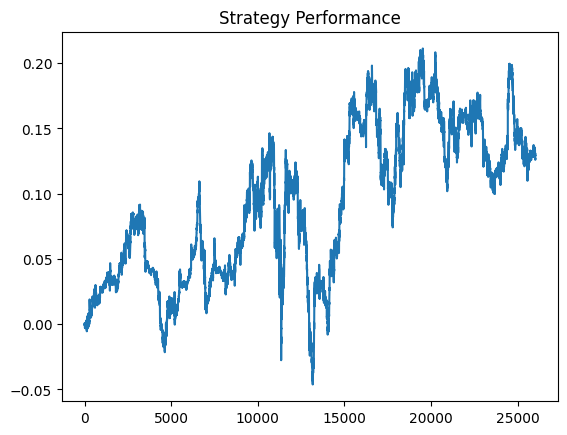

In [68]:
import matplotlib.pyplot as plt

plt.plot(cumulative_strategy, label="Model")
plt.title("Strategy Performance")
plt.show()

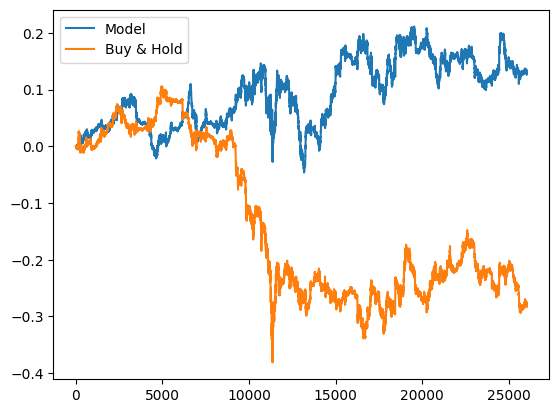

In [69]:
plt.plot(cumulative_strategy, label="Model")
plt.plot(cumulative_buy_hold, label="Buy & Hold")
plt.legend()
plt.show()

In [70]:
sharpe = np.mean(strategy_returns) / np.std(strategy_returns)
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.0028968406235396846
